# A price chart with no market data

Every insider transaction reports the price it executed at. Plot two
years of Form 4 prices for a liquid name and the stock's price path
emerges from regulatory filings alone: no exchange feed, no vendor, no
subscription. Just normalized EDGAR data.

Needs `pandas` and `matplotlib`, and a free API key in
`THREESPREAD_API_KEY` ([signup](https://3spread.com/auth/signup)).

In [1]:
import datetime as dt

import pandas as pd

from py3spread import Client

TICKER = "AAPL"
client = Client()

end = dt.date.today()
start = end - dt.timedelta(days=729)  # max window with an identity filter

rows = {}
for txn in client.insiders.iter_transactions(
    issuer_ticker=TICKER,
    transaction_start=str(start),
    transaction_end=str(end),
    transaction_kind="nonderiv",
):
    accession = txn["filing_id"].split("_", 1)[1]
    rows[(accession, txn["record_index"])] = txn

df = pd.DataFrame(rows.values())
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["price"] = pd.to_numeric(df["transaction_price_per_share"], errors="coerce")
df["value"] = pd.to_numeric(df["transaction_total_value"], errors="coerce")
priced = df[df["price"] > 0]  # drop gifts and zero-price grants
print(f"{len(df)} transactions, {len(priced)} carry an execution price")

142 transactions, 96 carry an execution price


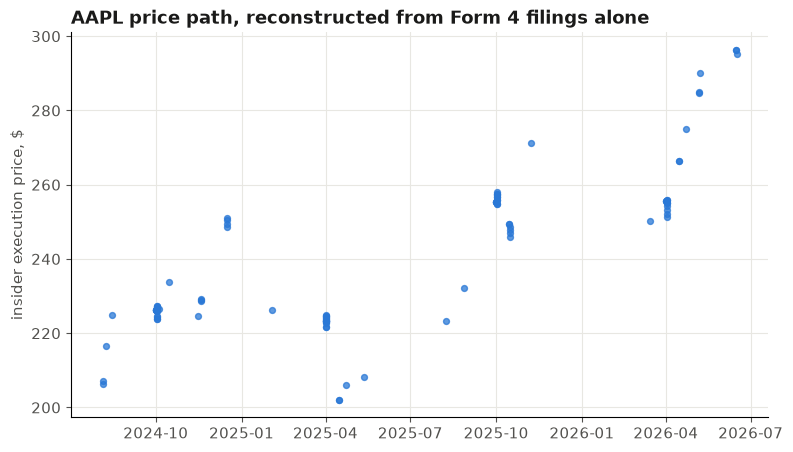

In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e8e7e2",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 11,
    "text.color": "#1a1a19",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
})
BLUE = "#2a78d6"
INK = "#52514e"


fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(priced["transaction_date"], priced["price"],
           s=18, color=BLUE, alpha=0.75)
ax.set_title(f"{TICKER} price path, reconstructed from Form 4 filings alone",
             loc="left", fontweight="bold")
ax.set_ylabel("insider execution price, $")
plt.show()

Each dot is a real insider execution. Density follows the trading
windows after earnings, and the envelope traces the market price.

The same field supports harder questions: how far from the prevailing
price do insiders transact, do option exercises cluster before runs, is
anyone consistently well-timed? All of it is one filter away in the
same stream, for any of the 9,500+ issuers with insider filings.